In [15]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names




In [16]:
def load_words_from_file(file_path):
    """从文件中读取内容并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set):
    """去除文本中的标点符号和停用词"""
    # 去除标点符号
    text = ''.join(char for char in text if char not in punctuation_set)
    # 去除停用词
    words = text.split()
    words = [word for word in words if word not in stopwords_set]
    return ' '.join(words)

def process_text_list(text_list, punctuation_file, stopwords_file):
    """处理文本列表，去除标点符号和停用词"""
    # 加载标点符号和停用词
    punctuation_set = load_words_from_file(punctuation_file)
    stopwords_set = load_words_from_file(stopwords_file)
    
    # 处理每个文本
    processed_list = []
    for text in text_list:
        processed_text = remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set)
        processed_list.append(processed_text)
    
    return processed_list






In [17]:
import jieba

def load_stopwords(file_path):
    """从文件中加载停用词并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_stopwords(words, stopwords_set):
    """去除分词结果中的停用词"""
    return [word for word in words if word not in stopwords_set]

def process_text_list111(text_list, stopwords_file):
    """处理文本列表，分词并去除停用词，最后取前500个分词"""
    # 加载停用词
    stopwords_set = load_stopwords(stopwords_file)
    
    # 处理每个文本
    processed_list = []
    i=0
    lll=len(text_list)
    for text in text_list:
        print(f"分词步骤已完成{i/lll*100} %")
        i+=1
        # 分词
        words = jieba.lcut(text)
        # 去除停用词
        words = remove_stopwords(words, stopwords_set)
        # 取前500个分词
        words = words
        processed_list.append(words)
    
    return processed_list



In [18]:
'''
import pandas as pd
import re

# 示例数据（假设这是 jieba 分词的结果）
data = processed_list1

# 清洗非法字符的函数
def clean_illegal_characters(text):
    # 使用正则表达式去除控制字符（ASCII 0-31）和其他非法字符
    if isinstance(text, str):
        return re.sub(r'[\x00-\x1F\x7F]', '', text)
    return text

# 清洗数据
cleaned_data = [[clean_illegal_characters(word) for word in sublist] for sublist in data]

# 将列表转换为 DataFrame，每一列对应一个子列表
max_length = max(len(sublist) for sublist in cleaned_data)  # 找到最长的子列表长度
df = pd.DataFrame({f"Column_{i+1}": sublist + [""] * (max_length - len(sublist)) for i, sublist in enumerate(cleaned_data)})

# 保存到 Excel 文件
df.to_excel("preprocessed_saved.xlsx", index=False, engine="openpyxl")

print("数据已保存到 preprocessed_saved.xlsx")'
'''

'\nimport pandas as pd\nimport re\n\n# 示例数据（假设这是 jieba 分词的结果）\ndata = processed_list1\n\n# 清洗非法字符的函数\ndef clean_illegal_characters(text):\n    # 使用正则表达式去除控制字符（ASCII 0-31）和其他非法字符\n    if isinstance(text, str):\n        return re.sub(r\'[\x00-\x1f\x7f]\', \'\', text)\n    return text\n\n# 清洗数据\ncleaned_data = [[clean_illegal_characters(word) for word in sublist] for sublist in data]\n\n# 将列表转换为 DataFrame，每一列对应一个子列表\nmax_length = max(len(sublist) for sublist in cleaned_data)  # 找到最长的子列表长度\ndf = pd.DataFrame({f"Column_{i+1}": sublist + [""] * (max_length - len(sublist)) for i, sublist in enumerate(cleaned_data)})\n\n# 保存到 Excel 文件\ndf.to_excel("preprocessed_saved.xlsx", index=False, engine="openpyxl")\n\nprint("数据已保存到 preprocessed_saved.xlsx")\'\n'

In [19]:
import random

def extract_paragraphs(tokenized_texts, num_paragraphs, paragraph_length):
    paragraphs = []  # 存储抽取的段落
    source_indices = []  # 存储段落的来源文本索引

    # 确保输入的文本足够长以抽取段落
    valid_texts = [text for text in tokenized_texts if len(text) >= paragraph_length]
    if not valid_texts:
        raise ValueError("没有足够长的文本可供抽取段落。")

    for _ in range(num_paragraphs):
        # 随机选择一个文本
        source_index = random.randint(0, len(valid_texts) - 1)
        source_text = valid_texts[source_index]

        # 随机抽取一个段落
        start = random.randint(0, len(source_text) - paragraph_length)
        paragraph = source_text[start:start + paragraph_length]

        # 存储段落及其来源索引
        paragraphs.append(paragraph)
        source_indices.append(source_index)

    return paragraphs, source_indices




In [20]:
def split_data(list1, list2, ratio=9):
    # 计算分割点
    split_point = int(len(list1) * ratio / (ratio + 1))
    
    # 分割第一个列表
    train_list1 = list1[:split_point]
    test_list1 = list1[split_point:]
    
    # 分割第二个列表
    train_list2 = list2[:split_point]
    test_list2 = list2[split_point:]
    
    return train_list1, test_list1, train_list2, test_list2





In [21]:
from gensim.models import LdaModel
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

In [22]:
from sklearn import svm
from gensim.models import LdaModel
import numpy as np

# 假设你已经有了训练好的LDA模型和训练数据
# lda_model: 训练好的LDA模型
# train_tokenized_texts: 第一个列表，包含分词后的文本片段
# train_text_indices: 第二个列表，包含每个文本片段对应的文本索引
from gensim.corpora import Dictionary



def transform_to_lda_features(lda_model, tokenized_texts):
    """
    将分词后的文本片段转换为LDA主题分布向量
    """
    lda_features = []
    for tokens in tokenized_texts:
        # 手动构建词袋模型
        bow = [(lda_model.id2word.token2id[token], 1) for token in tokens if token in lda_model.id2word.token2id]
        topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
        topic_vector = [prob for _, prob in topic_distribution]  # 提取主题概率
        lda_features.append(topic_vector)
    return np.array(lda_features)



def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()



In [23]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(y_true, y_pred):
    """
    计算模型预测的准确率

    参数:
    y_true (list): 真实的文本索引列表
    y_pred (list): 模型预测的文本索引列表

    返回:
    float: 预测准确率
    """
    return accuracy_score(y_true, y_pred)

In [24]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report



def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()



In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_vs_predicted(y_true, y_pred):
    """
    绘制真实值 vs 预测值图，并以 y = x 直线为参考

    参数:
    y_true (list or np.array): 真实值列表
    y_pred (list or np.array): 预测值列表
    """
    # 将输入转换为 numpy 数组
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 创建画布
    plt.figure(figsize=(8, 6))

    # 绘制 y = x 参考线
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 
             color='red', linestyle='--', label='y = x')

    # 绘制真实值 vs 预测值的散点图
    plt.scatter(y_true, y_pred, alpha=0.6, label='预测值 vs 真实值')

    # 添加标题和标签
    plt.title('真实值 vs 预测值', fontsize=16)
    plt.xlabel('真实值', fontsize=14)
    plt.ylabel('预测值', fontsize=14)

    # 添加网格
    plt.grid(True, linestyle='--', alpha=0.6)

    # 显示图例
    plt.legend()

    # 显示图像
    plt.show()

In [26]:
def plot_true_vs_predicted_with_accuracy(y_true, y_pred):
    """
    绘制真实值 vs 预测值图，并显示准确率
    """
    # 计算准确率
    accuracy = accuracy_score(y_true, y_pred)

    # 绘制图像
    plot_true_vs_predicted(y_true, y_pred)



    # 显示图像
    plt.show()

'''
# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 使用示例
y_true = test_list2
y_pred = predicted_indices1
plot_true_vs_predicted_with_accuracy(y_true, y_pred)'
'''

"\n# 设置支持中文的字体\nplt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体\nplt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题\n# 使用示例\ny_true = test_list2\ny_pred = predicted_indices1\nplot_true_vs_predicted_with_accuracy(y_true, y_pred)'\n"

In [27]:
'''
import matplotlib.pyplot as plt
import numpy as np

# 假设我们有以下数据（您需要用实际数据替换这些值）
# 网格搜索前的准确率（原始SVM模型）
original_accuracy = accuracy  # 替换为您实际的原始模型准确率

# 网格搜索后的准确率（最佳模型）
best_accuracy = accuracy1

# 模型标签
models = ['Original SVM', 'Optimized SVM (Grid Search)']

# 准确率值
accuracies = [original_accuracy, best_accuracy]

# 创建柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])

# 添加准确率数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

# 设置图表标题和标签
plt.title('Comparison of Model Accuracies: Before vs After Grid Search', pad=20)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)  # 设置y轴范围，留出空间给数值标签

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图表
plt.tight_layout()
plt.show()'
'''

"\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# 假设我们有以下数据（您需要用实际数据替换这些值）\n# 网格搜索前的准确率（原始SVM模型）\noriginal_accuracy = accuracy  # 替换为您实际的原始模型准确率\n\n# 网格搜索后的准确率（最佳模型）\nbest_accuracy = accuracy1\n\n# 模型标签\nmodels = ['Original SVM', 'Optimized SVM (Grid Search)']\n\n# 准确率值\naccuracies = [original_accuracy, best_accuracy]\n\n# 创建柱状图\nplt.figure(figsize=(10, 6))\nbars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])\n\n# 添加准确率数值标签\nfor bar in bars:\n    height = bar.get_height()\n    plt.text(bar.get_x() + bar.get_width()/2., height,\n             f'{height:.3f}',\n             ha='center', va='bottom')\n\n# 设置图表标题和标签\nplt.title('Comparison of Model Accuracies: Before vs After Grid Search', pad=20)\nplt.ylabel('Accuracy')\nplt.ylim(0, 1.1)  # 设置y轴范围，留出空间给数值标签\n\n# 显示网格线\nplt.grid(axis='y', linestyle='--', alpha=0.7)\n\n# 显示图表\nplt.tight_layout()\nplt.show()'\n"

In [ ]:
folder_path = 'C:\Users\ASUS\Desktop\研一（下）\dlnlp\第二次大作业\jyxstxtqj_downcc.com'
contents, names = read_txt_files_with_different_encodings(folder_path)

# 示例使用
text_list = contents
punctuation_file = 'cn_punctuation.txt'
stopwords_file = 'cn_stopwords.txt'
processed_list = process_text_list(text_list, punctuation_file, stopwords_file)

# 示例使用
text_list = processed_list
stopwords_file = 'cn_stopwords.txt'
processed_list1 = process_text_list111(text_list, stopwords_file)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\86157\AppData\Local\Temp\jieba.cache


分词步骤已完成0.0 %


Loading model cost 0.560 seconds.
Prefix dict has been built successfully.


分词步骤已完成5.88235294117647 %
分词步骤已完成11.76470588235294 %
分词步骤已完成17.647058823529413 %
分词步骤已完成23.52941176470588 %
分词步骤已完成29.411764705882355 %
分词步骤已完成35.294117647058826 %
分词步骤已完成41.17647058823529 %
分词步骤已完成47.05882352941176 %
分词步骤已完成52.94117647058824 %
分词步骤已完成58.82352941176471 %
分词步骤已完成64.70588235294117 %
分词步骤已完成70.58823529411765 %
分词步骤已完成76.47058823529412 %
分词步骤已完成82.35294117647058 %
分词步骤已完成88.23529411764706 %
分词步骤已完成94.11764705882352 %


In [29]:
print(len(processed_list1))

17



开始处理 K=20, T=5
段落抽取 - 内存: 0.21MB | 耗时: 0.00s

============================== K=20 T=5 第1折交叉验证 ==============================
LDA训练 - 内存: 67.52MB | 耗时: 5.35s
特征转换 - 内存: 0.32MB | 耗时: 0.49s
[LibSVM]SVM训练 - 内存: 0.13MB | 耗时: 0.04s
Fold 1 准确率: 0.3000
预测评估 - 内存: 0.02MB | 耗时: 0.01s

============================== K=20 T=5 第2折交叉验证 ==============================
LDA训练 - 内存: 16.46MB | 耗时: 5.04s
特征转换 - 内存: -2.88MB | 耗时: 0.41s
[LibSVM]SVM训练 - 内存: -1.18MB | 耗时: 0.04s
Fold 2 准确率: 0.2200
预测评估 - 内存: 0.00MB | 耗时: 0.01s

============================== K=20 T=5 第3折交叉验证 ==============================
LDA训练 - 内存: 1.25MB | 耗时: 4.82s
特征转换 - 内存: 0.06MB | 耗时: 0.44s
[LibSVM]SVM训练 - 内存: -1.57MB | 耗时: 0.04s
Fold 3 准确率: 0.2500
预测评估 - 内存: 0.00MB | 耗时: 0.01s

============================== K=20 T=5 第4折交叉验证 ==============================
LDA训练 - 内存: 5.73MB | 耗时: 4.62s
特征转换 - 内存: -1.02MB | 耗时: 0.44s
[LibSVM]SVM训练 - 内存: -2.21MB | 耗时: 0.03s
Fold 4 准确率: 0.2100
预测评估 - 内存: 0.00MB | 耗时: 0.01s

==============================

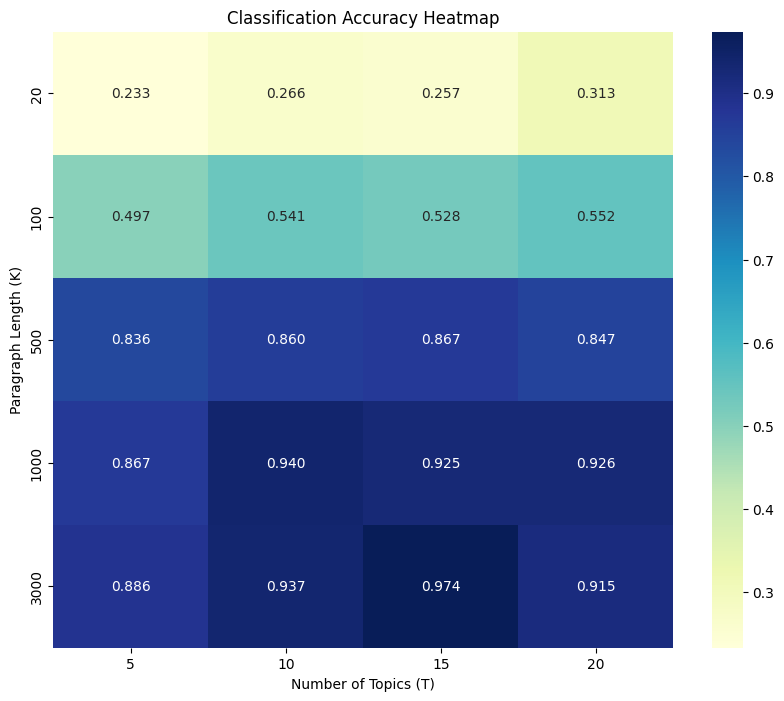

In [30]:
import numpy as np
from sklearn.model_selection import KFold
from joblib import Parallel, delayed
import psutil
import time
from contextlib import contextmanager
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# 超参数设置
LLL1 = [20, 100, 500, 1000, 3000]  # K值列表
TTT1 = [5, 10, 15, 20]              # T值列表
MMMMM = 1000                        # 最大段落长度
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
N_SPLITS = 10                       # 交叉验证次数

@contextmanager
def memory_monitor(label):
    """带超时机制的内存监控"""
    proc = psutil.Process()
    start_mem = proc.memory_info().rss / 1024 / 1024
    start_time = time.time()
    timeout = 3600  # 1小时超时
    
    try:
        yield
    finally:
        if time.time() - start_time > timeout:
            raise TimeoutError(f"{label} 执行超时")
        end_mem = proc.memory_info().rss / 1024 / 1024
        print(f"{label} - 内存: {end_mem-start_mem:.2f}MB | 耗时: {time.time()-start_time:.2f}s")

def cross_validate(processed_list, paragraphs, source_indices, K, T):
    """执行10折交叉验证的核心函数"""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_accuracies = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(paragraphs), 1):
        print(f"\n{'='*30} K={K} T={T} 第{fold}折交叉验证 {'='*30}")
        
        # 划分训练测试集
        train_para = [paragraphs[i] for i in train_idx]
        test_para = [paragraphs[i] for i in test_idx]
        train_src = [source_indices[i] for i in train_idx]
        test_src = [source_indices[i] for i in test_idx]
        
        # LDA训练
        with memory_monitor("LDA训练"):
            dictionary = Dictionary(processed_list)
            corpus = [dictionary.doc2bow(text) for text in processed_list]
            lda_model = LdaModel(
                corpus=corpus,
                id2word=dictionary,
                num_topics=T,
                chunksize=1000,
                passes=1,
                iterations=50
            )
        
        # 特征转换
        with memory_monitor("特征转换"):
            X_train = transform_to_lda_features(lda_model, train_para)
            X_test = transform_to_lda_features(lda_model, test_para)
        
        # SVM训练（简化参数）
        with memory_monitor("SVM训练"):
            svm_model = svm.SVC(
                C=10,  # 使用经验值避免网格搜索
                kernel='rbf',
                gamma='scale',
                verbose=True
            )
            svm_model.fit(X_train, train_src)
        
        # 评估
        with memory_monitor("预测评估"):
            pred = svm_model.predict(X_test)
            acc = calculate_accuracy(test_src, pred)
            fold_accuracies.append(acc)
            print(f"Fold {fold} 准确率: {acc:.4f}")
    
    return np.mean(fold_accuracies), np.std(fold_accuracies)

def process_k_t_value(K, T, processed_list):
    """处理单个K和T值的完整流程（带交叉验证）"""
    print(f"\n{'='*40}\n开始处理 K={K}, T={T}\n{'='*40}")
    
    try:
        # 阶段1: 数据准备
        with memory_monitor("段落抽取"):
            paragraphs, source_indices = extract_paragraphs(
                processed_list, MMMMM, K
            )
        
        # 执行交叉验证
        mean_acc, std_acc = cross_validate(processed_list, paragraphs, source_indices, K, T)
        
        print(f"\nK={K}, T={T} 交叉验证结果: {mean_acc:.4f} ± {std_acc:.4f}")
        return (K, T, mean_acc, std_acc)
    
    except Exception as e:
        print(f"K={K}, T={T} 处理失败: {str(e)}")
        return (K, T, 0, 0)

def create_heatmap(results):
    """根据结果创建热力图"""
    # 准备数据
    K_values = sorted(list(set(r[0] for r in results)))
    T_values = sorted(list(set(r[1] for r in results)))
    
    # 创建准确率矩阵
    acc_matrix = np.zeros((len(K_values), len(T_values)))
    for r in results:
        k_idx = K_values.index(r[0])
        t_idx = T_values.index(r[1])
        acc_matrix[k_idx, t_idx] = r[2]
    
    # 绘制热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(acc_matrix, 
                annot=True, 
                fmt=".3f",
                xticklabels=T_values,
                yticklabels=K_values,
                cmap="YlGnBu")
    plt.xlabel("Number of Topics (T)")
    plt.ylabel("Paragraph Length (K)")
    plt.title("Classification Accuracy Heatmap")
    plt.savefig("accuracy_heatmap.png")
    plt.show()

# 主执行流程
if __name__ == "__main__":
    # 小规模测试
    test_results = []
    for K in [20, 100]:
        for T in [5, 10]:
            _, _, acc, std = process_k_t_value(K, T, processed_list1)
            test_results.append(acc > 0)
            print(f"K={K}, T={T} 测试完成: {acc:.4f} ± {std:.4f}")
    
    if all(test_results):
        print("\n小K/T值测试成功，开始完整运行...")
        # 生成所有K和T的组合
        param_combinations = [(K, T) for K in LLL1 for T in TTT1]
        
        # 限制并行进程数
        results = Parallel(n_jobs=4)(
            delayed(process_k_t_value)(K, T, processed_list1)
            for K, T in param_combinations
        )
        
        # 结果展示
        print("\n最终交叉验证结果:")
        for K, T, acc, std in results:
            print(f"K={K:<5} T={T:<3} 平均准确率: {acc:.4f} ± {std:.4f}")
        
        # 创建热力图
        create_heatmap(results)
    else:
        print("\n小K/T值测试失败，请检查错误")